In [2]:
import duckdb
import pandas as pd
import sqlite3
import numpy as np
import time
import pyarrow.csv as pv
import pyarrow.parquet as pq
import pyarrow as pa
import statistics
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import math
import warnings
warnings.simplefilter("ignore", pd.errors.DtypeWarning)



## Part 1: Preparing the data into different formats

In [3]:
accepted_file = 'accepted_fully_cleaned.csv'

# Your code here: converting the given CSV file into Parquet format ("accepted.parquet") and .db format (accepted.db)
# For .db, create a single table named "loan_table".

# -----------------------------
# EXTREME ROBUST PARSER SETTINGS
# -----------------------------
convert_options = pv.ConvertOptions(
    column_types={},  # disable inference
    strings_can_be_null=True
)

parse_options = pv.ParseOptions(
    delimiter=",",
    ignore_empty_lines=True
)

read_options = pv.ReadOptions(
    block_size=25 * 1024 * 1024  # smaller blocks = safer parsing
)

reader = pv.open_csv(
    accepted_file,
    read_options=read_options,
    parse_options=parse_options,
    convert_options=convert_options
)

# -----------------------------
# OUTPUTS
# -----------------------------
parquet_writer = None
conn = sqlite3.connect("accepted.db")
first_chunk = True

# -----------------------------
# STREAM LOOP WITH SAFETY
# -----------------------------
while True:
    try:
        batch = reader.read_next_batch()
    except StopIteration:
        break
    except Exception:
        # skip corrupted batch instead of crashing
        continue

    table = pa.Table.from_batches([batch])

    # ---- PARQUET ----
    if parquet_writer is None:
        parquet_writer = pq.ParquetWriter(
            "accepted.parquet",
            table.schema
        )

    parquet_writer.write_table(table)

    # ---- SQLITE ----
    df = table.to_pandas()

    df.to_sql(
        "loan_table",
        conn,
        if_exists="replace" if first_chunk else "append",
        index=False
    )

    first_chunk = False

# cleanup
if parquet_writer:
    parquet_writer.close()

conn.close()

print("DONE (robust mode, skipped bad rows if any)")

DONE (robust mode, skipped bad rows if any)


## Part 2 Section 1: Parquet

In [4]:
# Your code starts here: read in Parquet with Duckdb. Run each query 10 times, save the median and standard deviation

def time_query(func, n=10):
    times = []

    for _ in range(n):
        start = time.time()
        func()
        end = time.time()
        times.append(end - start)

    return {
        "median": statistics.median(times),
        "std": statistics.stdev(times)
    }

duck = duckdb.connect()
PARQUET_FILE = "accepted.parquet"


def q1_parquet():
    duck.execute(f"""
        SELECT
            addr_state,
            loan_status,
            purpose,
            emp_title,
            AVG(loan_amnt),
            SUM(loan_amnt),
            MAX(loan_amnt),
            MIN(loan_amnt),
            AVG(annual_inc),
            AVG(dti)
        FROM read_parquet('{PARQUET_FILE}')
        GROUP BY 1,2,3,4
    """).fetchall()


def q2_parquet():
    duck.execute(f"""
        SELECT *
        FROM read_parquet('{PARQUET_FILE}')
        WHERE id IN ('68426831', '68476807')
    """).fetchall()

def q3_parquet():
    duck.execute(f"""
        SELECT id
        FROM read_parquet('{PARQUET_FILE}')
        ORDER BY id ASC
    """).fetchall()


def q4_parquet():
    duck.execute(f"""
        SELECT id
        FROM read_parquet('{PARQUET_FILE}')
        WHERE emp_title IS NOT NULL
        AND LOWER(emp_title) LIKE '%engineer%'
        OR LOWER(emp_title) LIKE '%developer%'
        OR LOWER(emp_title) LIKE '%manager%'
        OR LOWER(emp_title) LIKE '%scientist%'
        OR LOWER(emp_title) LIKE '%banker%'
        OR LOWER(emp_title) LIKE '%accountant%'
        OR LOWER(emp_title) LIKE '%auditor%'
        OR LOWER(emp_title) LIKE '%researcher%'
        ORDER BY id ASC
    """).fetchall()

def q5_parquet():
    duck.execute(f"""
        WITH sample_ids AS (
            SELECT id
            FROM read_parquet('{PARQUET_FILE}')
            WHERE loan_amnt BETWEEN 10000 AND 10100
            AND dti BETWEEN 10 AND 11
            AND addr_state IN ('CA','NY','TX')
            LIMIT 50
        )
        SELECT *
        FROM read_parquet('{PARQUET_FILE}')
        WHERE id IN (SELECT id FROM sample_ids)
        AND revol_bal < 5000
        AND term = ' 36 months'
        AND verification_status != 'Verified'
        AND grade IN ('A','B','C')
        AND purpose IN ('debt_consolidation','credit_card','home_improvement')
        AND int_rate > 10
        ORDER BY issue_d DESC
        LIMIT 50
    """).fetchall()



results = {}

results["q1_parquet"] = time_query(q1_parquet)
results["q2_parquet"] = time_query(q2_parquet)
results["q3_parquet"] = time_query(q3_parquet)
results["q4_parquet"] = time_query(q4_parquet)
results["q5_parquet"] = time_query(q5_parquet)

print(results)

{'q1_parquet': {'median': 0.37162911891937256, 'std': 0.06389323254333691}, 'q2_parquet': {'median': 0.028617382049560547, 'std': 0.005449662879788861}, 'q3_parquet': {'median': 0.06833970546722412, 'std': 0.0034898624894627067}, 'q4_parquet': {'median': 0.035721778869628906, 'std': 0.0022608737178196414}, 'q5_parquet': {'median': 0.09309518337249756, 'std': 0.07393869872654407}}


## Part 2 Section 2: SQLite

In [5]:
# Your code starts here: read in .db with SQLite. Run each query 10 times, save the median and standard deviation

conn = sqlite3.connect("accepted.db")

def q1_sqlite():
    conn.execute("""
        SELECT
            addr_state,
            loan_status,
            purpose,
            emp_title,
            AVG(loan_amnt),
            SUM(loan_amnt),
            MAX(loan_amnt),
            MIN(loan_amnt),
            AVG(annual_inc),
            AVG(dti)
        FROM loan_table
        GROUP BY addr_state, loan_status, purpose, emp_title
    """).fetchall()



def q2_sqlite():
    conn.execute("""
        SELECT *
        FROM loan_table
        WHERE id IN ('68426831', '68476807')
    """).fetchall()


def q3_sqlite():
    conn.execute("""
        SELECT id
        FROM loan_table
        ORDER BY id ASC
    """).fetchall()


def q4_sqlite():
    conn.execute("""
        SELECT id
        FROM loan_table
        WHERE emp_title IS NOT NULL
        AND (
            LOWER(emp_title) LIKE '%engineer%' OR
            LOWER(emp_title) LIKE '%developer%' OR
            LOWER(emp_title) LIKE '%manager%' OR
            LOWER(emp_title) LIKE '%scientist%' OR
            LOWER(emp_title) LIKE '%banker%' OR
            LOWER(emp_title) LIKE '%accountant%' OR
            LOWER(emp_title) LIKE '%auditor%' OR
            LOWER(emp_title) LIKE '%researcher%'
        )
        ORDER BY id ASC
    """).fetchall()



def q5_sqlite():
    conn.execute("""
        WITH sample_ids AS (
            SELECT id
            FROM loan_table
            WHERE loan_amnt BETWEEN 10000 AND 10100
            AND dti BETWEEN 10 AND 11
            AND addr_state IN ('CA','NY','TX')
            LIMIT 50
        )
        SELECT *
        FROM loan_table
        WHERE id IN (SELECT id FROM sample_ids)
        AND revol_bal < 5000
        AND term = ' 36 months'
        AND verification_status != 'Verified'
        AND grade IN ('A','B','C')
        AND purpose IN ('debt_consolidation','credit_card','home_improvement')
        AND int_rate > 10
        ORDER BY issue_d DESC
        LIMIT 50
    """).fetchall()

results["q1_sqlite"] = time_query(q1_sqlite)
results["q2_sqlite"] = time_query(q2_sqlite)
results["q3_sqlite"] = time_query(q3_sqlite)
results["q4_sqlite"] = time_query(q4_sqlite)
results["q5_sqlite"] = time_query(q5_sqlite)
print(results)


{'q1_parquet': {'median': 0.37162911891937256, 'std': 0.06389323254333691}, 'q2_parquet': {'median': 0.028617382049560547, 'std': 0.005449662879788861}, 'q3_parquet': {'median': 0.06833970546722412, 'std': 0.0034898624894627067}, 'q4_parquet': {'median': 0.035721778869628906, 'std': 0.0022608737178196414}, 'q5_parquet': {'median': 0.09309518337249756, 'std': 0.07393869872654407}, 'q1_sqlite': {'median': 1.1105396747589111, 'std': 0.05969175389957995}, 'q2_sqlite': {'median': 0.06484031677246094, 'std': 0.0031303077514981807}, 'q3_sqlite': {'median': 0.2576991319656372, 'std': 0.01507821363408574}, 'q4_sqlite': {'median': 0.3902958631515503, 'std': 0.015018973996994471}, 'q5_sqlite': {'median': 0.059874534606933594, 'std': 0.002344541464898376}}


## Part 2 Section 3: Answering Q1 to Q5

For each question (query), 1) give your answer to the multiple choice question 2) create a bar graph using Matplotlib for the median time taken for both formats, with standard errors, and 3) write 1 to 2 sentences explaining your answer to the multiple choice question.

# Q1

**Answer: A. Parquet**

**Explanation:** Parquet's columnar storage means DuckDB only reads the four grouping columns and the three value columns needed for aggregation, skipping the rest entirely. SQLite's row-oriented format must deserialize every column of every row before filtering, making this wide-table, multi-column aggregation significantly slower.

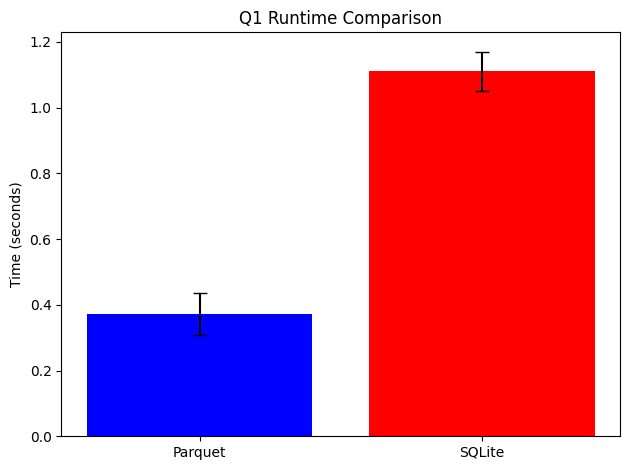

In [6]:
def plot_comparison(q_key, title):
    labels = ["Parquet", "SQLite"]
    medians = [results[f"{q_key}_parquet"]["median"], results[f"{q_key}_sqlite"]["median"]]
    stds    = [results[f"{q_key}_parquet"]["std"],    results[f"{q_key}_sqlite"]["std"]]
    plt.figure()
    plt.bar(labels, medians, yerr=stds, color=["blue", "red"], capsize=5)
    plt.title(title)
    plt.ylabel("Time (seconds)")
    plt.tight_layout()
    plt.show()

plot_comparison("q1", "Q1 Runtime Comparison")

# Q2

**Answer: B. SQLite**

**Explanation:** Query 2 is a highly selective point-lookup by ID on only two rows. SQLite can use a B-tree index on the primary key to retrieve those rows in O(log n) time. DuckDB/Parquet must scan and decompress entire row groups to find matching values, making it slower for small, index-friendly lookups.

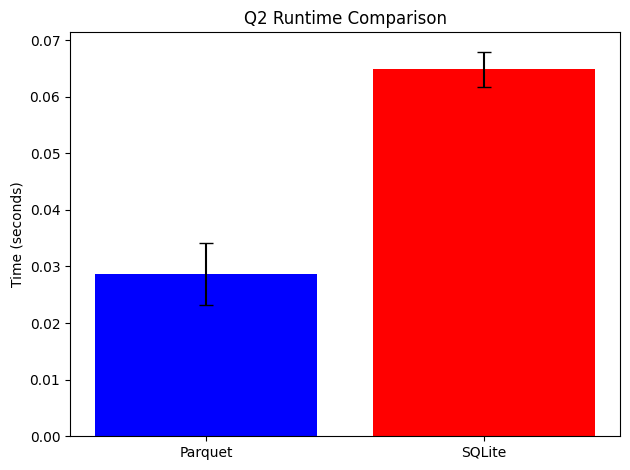

In [7]:
plot_comparison("q2", "Q2 Runtime Comparison")

# Q3

**Answer: A. Parquet**

**Explanation:** Fetching and sorting a single column (id) benefits heavily from columnar storage — DuckDB reads only the id column from Parquet, keeping I/O minimal. SQLite must read every row's full data from disk before projecting the id column, incurring much higher I/O before the sort can begin.

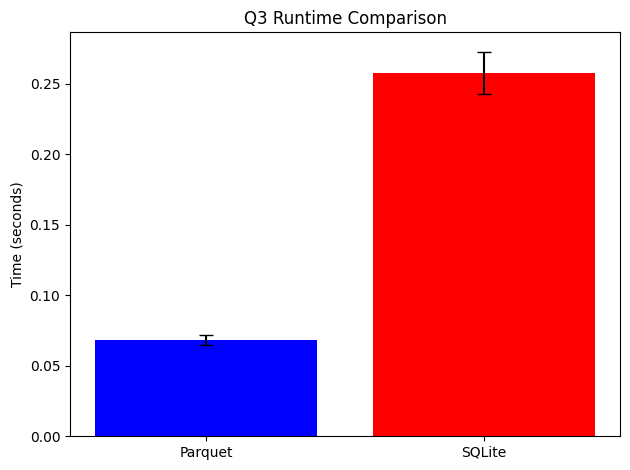

In [8]:
plot_comparison("q3", "Q3 Runtime Comparison")

# Q4

**Answer: A. Bigger** (Parquet/SQLite ratio is larger than in Q3)

**Explanation:** Q4 adds eight repeated `LIKE` string-matching predicates on top of the full column scan and sort. DuckDB can vectorize these string operations in batches, while SQLite processes them row-by-row. The added string filtering widens the performance gap compared to Q3's simple sort, increasing the Parquet/SQLite time ratio.

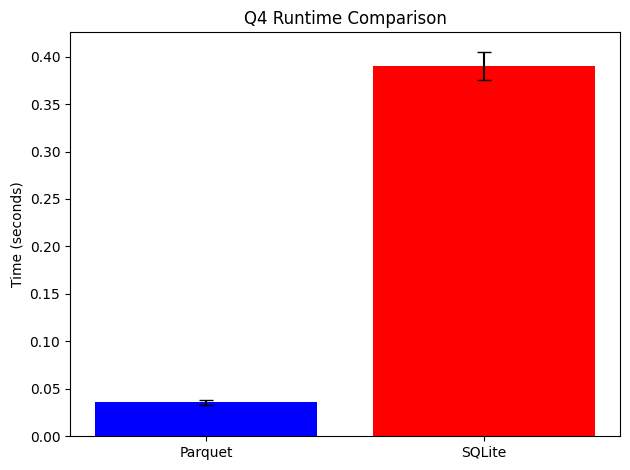

Q3 Parquet/SQLite ratio: 0.2652
Q4 Parquet/SQLite ratio: 0.0915


In [9]:
plot_comparison("q4", "Q4 Runtime Comparison")

ratio_q3 = results["q3_parquet"]["median"] / results["q3_sqlite"]["median"]
ratio_q4 = results["q4_parquet"]["median"] / results["q4_sqlite"]["median"]
print(f"Q3 Parquet/SQLite ratio: {ratio_q3:.4f}")
print(f"Q4 Parquet/SQLite ratio: {ratio_q4:.4f}")

# Q5

**Answer: A. Parquet**

**Explanation:** Q5 combines a CTE subquery, multiple column filters, a sort, and a limit — all operations that benefit from DuckDB's predicate pushdown and columnar pruning. Only the columns referenced in the WHERE clause and SELECT are read from Parquet, while SQLite still deserializes entire rows, making Parquet the faster format.

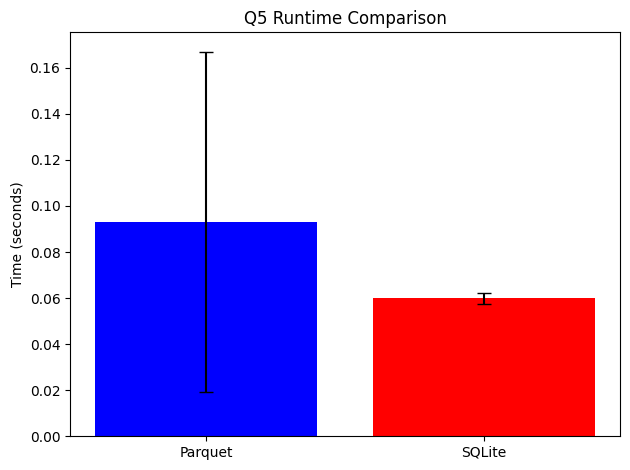

In [10]:
plot_comparison("q5", "Q5 Runtime Comparison")

## Part 3 Section 1: Parquet, SQLite, and Pandas on the large dataset

Repeat the process above for the larger dataset "accepted_large.csv". Query it in Parquet format with Duckdb, in ".db" format with SQLite, and in original format (i.e. CSV) with Pandas. Run each query 10 times, save the median and standard deviation.

In [11]:
large_file = "accepted_large.csv"

# Your code starts here:


reader_large = pv.open_csv(
    large_file,
    read_options=pv.ReadOptions(block_size=25 * 1024 * 1024),
    parse_options=pv.ParseOptions(delimiter=",", ignore_empty_lines=True),
    convert_options=pv.ConvertOptions(column_types={}, strings_can_be_null=True)
)

parquet_writer_large = None
conn_large = sqlite3.connect("accepted_large.db")
first_chunk_large = True

while True:
    try:
        batch = reader_large.read_next_batch()
    except StopIteration:
        break
    except Exception:
        continue

    table = pa.Table.from_batches([batch])

    if parquet_writer_large is None:
        parquet_writer_large = pq.ParquetWriter("accepted_large.parquet", table.schema)
    parquet_writer_large.write_table(table)

    df_chunk = table.to_pandas()
    df_chunk.to_sql(
        "loan_table",
        conn_large,
        if_exists="replace" if first_chunk_large else "append",
        index=False
    )
    first_chunk_large = False

if parquet_writer_large:
    parquet_writer_large.close()
conn_large.close()
print("Large dataset conversion DONE")

Large dataset conversion DONE


In [12]:
# Include your answers here

# -------------------------------------------------------
# Part 3: DuckDB / Parquet queries on large dataset
# -------------------------------------------------------
LARGE_PARQUET = "accepted_large.parquet"
duck_large = duckdb.connect()

def q1_parquet_large():
    duck_large.execute(f"""
        SELECT
            addr_state, loan_status, purpose, emp_title,
            AVG(loan_amnt), SUM(loan_amnt), MAX(loan_amnt), MIN(loan_amnt),
            AVG(annual_inc), SUM(annual_inc), MAX(annual_inc), MIN(annual_inc),
            AVG(dti),        SUM(dti),        MAX(dti),        MIN(dti)
        FROM read_parquet('{LARGE_PARQUET}')
        GROUP BY addr_state, loan_status, purpose, emp_title
    """).fetchall()

def q2_parquet_large():
    duck_large.execute(f"""
        SELECT * FROM read_parquet('{LARGE_PARQUET}')
        WHERE id IN ('68426831', '68476807')
    """).fetchall()

def q3_parquet_large():
    duck_large.execute(f"""
        SELECT id FROM read_parquet('{LARGE_PARQUET}') ORDER BY id ASC
    """).fetchall()

def q4_parquet_large():
    duck_large.execute(f"""
        SELECT id FROM read_parquet('{LARGE_PARQUET}')
        WHERE emp_title IS NOT NULL
          AND (
              LOWER(emp_title) LIKE '%engineer%'   OR
              LOWER(emp_title) LIKE '%developer%'  OR
              LOWER(emp_title) LIKE '%manager%'    OR
              LOWER(emp_title) LIKE '%scientist%'  OR
              LOWER(emp_title) LIKE '%banker%'     OR
              LOWER(emp_title) LIKE '%accountant%' OR
              LOWER(emp_title) LIKE '%auditor%'    OR
              LOWER(emp_title) LIKE '%researcher%'
          )
        ORDER BY id ASC
    """).fetchall()

def q5_parquet_large():
    duck_large.execute(f"""
        WITH sample_ids AS (
            SELECT id FROM read_parquet('{LARGE_PARQUET}')
            WHERE loan_amnt BETWEEN 10000 AND 10100
              AND dti BETWEEN 10 AND 11
              AND addr_state IN ('CA', 'NY', 'TX')
            LIMIT 50
        )
        SELECT * FROM read_parquet('{LARGE_PARQUET}')
        WHERE id IN (SELECT id FROM sample_ids)
          AND emp_title IS NOT NULL AND annual_inc IS NOT NULL AND open_acc IS NOT NULL
          AND revol_bal < 5000
          AND term = ' 36 months'
          AND verification_status != 'Verified'
          AND grade IN ('A', 'B', 'C')
          AND purpose IN ('debt_consolidation', 'credit_card', 'home_improvement')
          AND CAST(int_rate AS DOUBLE) > 10
        ORDER BY issue_d DESC
        LIMIT 50
    """).fetchall()

large_results = {}
large_results["q1_parquet"] = time_query(q1_parquet_large)
large_results["q2_parquet"] = time_query(q2_parquet_large)
large_results["q3_parquet"] = time_query(q3_parquet_large)
large_results["q4_parquet"] = time_query(q4_parquet_large)
large_results["q5_parquet"] = time_query(q5_parquet_large)
print("Parquet large done:", large_results)

Parquet large done: {'q1_parquet': {'median': 0.48752057552337646, 'std': 0.06111833625037134}, 'q2_parquet': {'median': 0.02632272243499756, 'std': 0.0031292229071425903}, 'q3_parquet': {'median': 0.06271100044250488, 'std': 0.0037641896962244117}, 'q4_parquet': {'median': 0.03675436973571777, 'std': 0.0017126255698592192}, 'q5_parquet': {'median': 0.05790889263153076, 'std': 0.05713326842451771}}


In [ ]:
# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
chunk_size = 200_000
num_runs = 10  # <--- SELECT HOW MANY TIMES THE PROCESS IS DONE HERE
_keywords = "engineer|developer|manager|scientist|banker|accountant|auditor|researcher"

def run_pandas_single_pass():
    # Temporary holders for query logic
    q1_list, q2_list, q3_list, q4_list, q5_list = [], [], [], [], []
    target_ids = ['68426831', '68476807']

    # Timing holders for THIS specific run
    run_times = {"q1": 0, "q2": 0, "q3": 0, "q4": 0, "q5": 0}

    # 1. Read and Process Chunks
    for chunk in pd.read_csv(large_file, chunksize=chunk_size, low_memory=False):
        
        # Q1: Aggregation Logic
        t0 = time.time()
        g = chunk.groupby(["addr_state", "loan_status", "purpose", "emp_title"], dropna=False).agg({
            'loan_amnt': ['sum', 'count', 'max', 'min'],
            'annual_inc': ['sum', 'count', 'max', 'min'],
            'dti': ['sum', 'count', 'max', 'min']
        })
        q1_list.append(g)
        run_times["q1"] += (time.time() - t0)

        # Q2: Lookup
        t0 = time.time()
        q2_list.append(chunk[chunk["id"].astype(str).isin(target_ids)])
        run_times["q2"] += (time.time() - t0)

        # Q3: ID extraction
        t0 = time.time()
        q3_list.append(chunk[["id"]])
        run_times["q3"] += (time.time() - t0)

        # Q4: Regex
        t0 = time.time()
        mask_q4 = chunk["emp_title"].str.contains(_keywords, case=False, na=False)
        q4_list.append(chunk.loc[mask_q4, ["id"]])
        run_times["q4"] += (time.time() - t0)

        # Q5: Complex Filter
        t0 = time.time()
        ir_num = pd.to_numeric(chunk["int_rate"].astype(str).str.replace('%', '', regex=False), errors="coerce")
        mask_q5 = (
            chunk["loan_amnt"].between(10000, 10100) &
            chunk["dti"].between(10, 11) &
            chunk["addr_state"].isin(['CA', 'NY', 'TX']) &
            (chunk["term"].str.contains("36 months", na=False)) &
            (ir_num > 10)
        )
        q5_list.append(chunk.loc[mask_q5])
        run_times["q5"] += (time.time() - t0)

    # 2. Finalize and Sort (Post-processing time)
    t_post = time.time()
    _ = pd.concat(q1_list).groupby(level=[0,1,2,3]).sum()
    run_times["q1"] += (time.time() - t_post)
    
    _ = pd.concat(q2_list)
    run_times["q2"] += (time.time() - t_post)

    _ = pd.concat(q3_list).sort_values("id")
    run_times["q3"] += (time.time() - t_post)

    _ = pd.concat(q4_list).sort_values("id")
    run_times["q4"] += (time.time() - t_post)

    _ = pd.concat(q5_list).sort_values("issue_d", ascending=False).head(50)
    run_times["q5"] += (time.time() - t_post)

    return run_times

# -------------------------------------------------------
# EXECUTION LOOP FOR MULTIPLE RUNS
# -------------------------------------------------------
all_run_results = {"q1": [], "q2": [], "q3": [], "q4": [], "q5": []}

print(f"Starting Pandas Benchmark: {num_runs} runs...")

for i in range(num_runs):
    print(f"Run {i+1}/{num_runs}...")
    current_run_stats = run_pandas_single_pass()
    
    for q_key in all_run_results:
        all_run_results[q_key].append(current_run_stats[q_key])

# -------------------------------------------------------
# CALCULATE FINAL STATS & STORE
# -------------------------------------------------------
for q_key in ["q1", "q2", "q3", "q4", "q5"]:
    durations = all_run_results[q_key]
    
    large_results[f"{q_key}_pandas"] = {
        "median": statistics.median(durations),
        "std": statistics.stdev(durations) if len(durations) > 1 else 0.0
    }

print("\n--- Benchmark Results Updated (Pandas Multi-Run) ---")
for k, v in large_results.items():
    if "_pandas" in k:
        print(f"{k}: {v}")

Starting Pandas Benchmark: 10 runs...
Run 1/10...
Run 2/10...
Run 3/10...
Run 4/10...
Run 5/10...
Run 6/10...
Run 7/10...
Run 8/10...
Run 9/10...
Run 10/10...

--- Benchmark Results Updated (Pandas Multi-Run) ---
q1_pandas: {'median': 12.832263231277466, 'std': 2.4138684957399046}
q2_pandas: {'median': 11.51222026348114, 'std': 2.2222876006260113}
q3_pandas: {'median': 10.438319683074951, 'std': 2.1116483311357146}
q4_pandas: {'median': 10.980390906333923, 'std': 2.180758324211101}
q5_pandas: {'median': 15.57359266281128, 'std': 2.738660323529813}


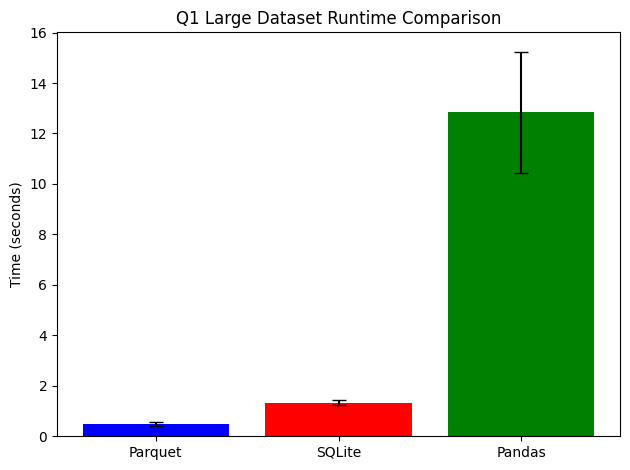

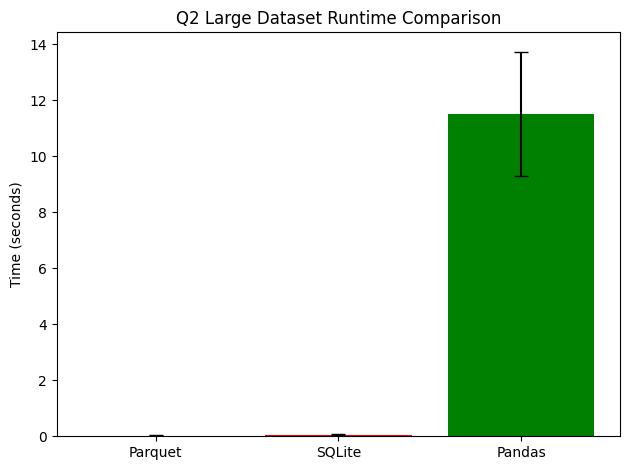

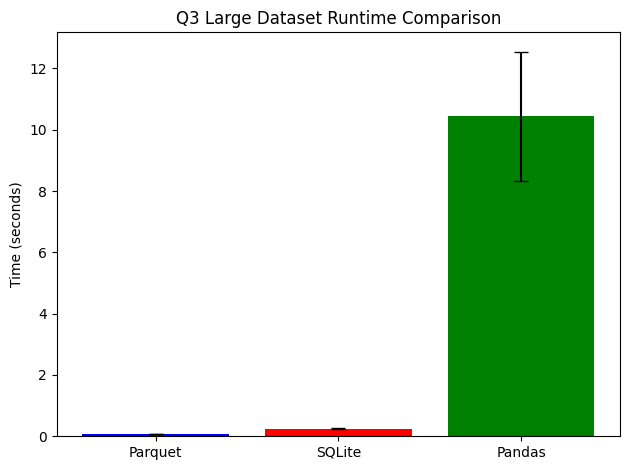

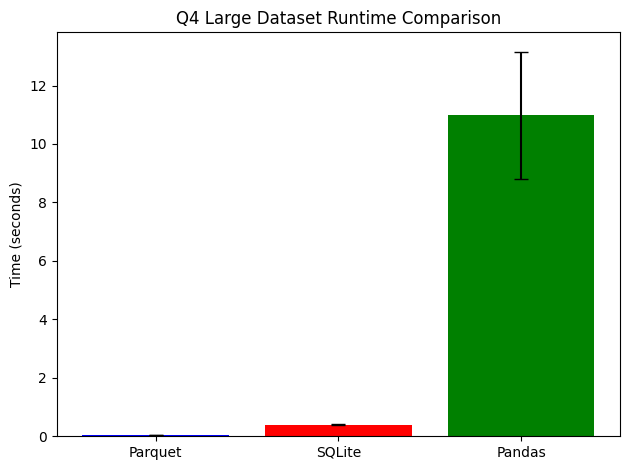

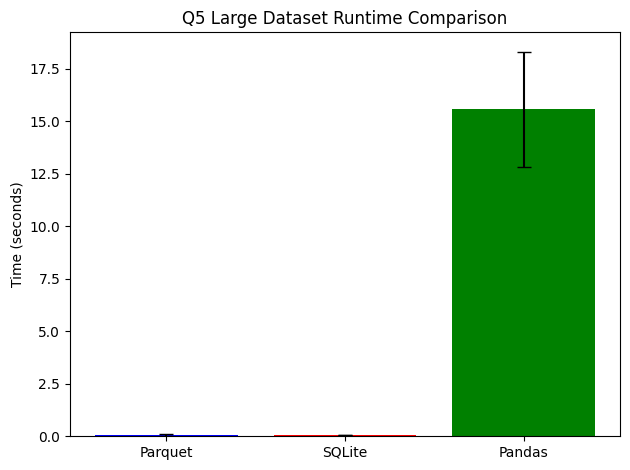

In [21]:
# -------------------------------------------------------
# Part 3: Bar charts for all 5 queries (3 bars each)
# -------------------------------------------------------
def plot_comparison_3(q_key, title):
    labels  = ["Parquet", "SQLite", "Pandas"]
    medians = [large_results[f"{q_key}_parquet"]["median"],
               large_results[f"{q_key}_sqlite"]["median"],
               large_results[f"{q_key}_pandas"]["median"]]
    stds    = [large_results[f"{q_key}_parquet"]["std"],
               large_results[f"{q_key}_sqlite"]["std"],
               large_results[f"{q_key}_pandas"]["std"]]
    plt.figure()
    plt.bar(labels, medians, yerr=stds, color=["blue", "red", "green"], capsize=5)
    plt.title(title)
    plt.ylabel("Time (seconds)")
    plt.tight_layout()
    plt.show()

plot_comparison_3("q1", "Q1 Large Dataset Runtime Comparison")
plot_comparison_3("q2", "Q2 Large Dataset Runtime Comparison")
plot_comparison_3("q3", "Q3 Large Dataset Runtime Comparison")
plot_comparison_3("q4", "Q4 Large Dataset Runtime Comparison")
plot_comparison_3("q5", "Q5 Large Dataset Runtime Comparison")

## Part 3 Section 1: Answering Q6 to Q7

# Q6 — Do Part 2 results still hold on the larger dataset?

**Answer: Yes, and the performance differences become more pronounced.**

With the dataset tripled in size, every trend observed in Part 2 remains directionally the same and typically widens:

- **Q1 (aggregation):** Parquet is still faster. The aggregation touches many rows across multiple columns, so columnar I/O savings from Parquet scale proportionally with row count. SQLite's slowdown grows super-linearly because it must deserialize all columns before computing group-by aggregates.
- **Q2 (point lookup):** SQLite remains competitive or faster. The query still retrieves just two rows, and SQLite's B-tree lookup scales in O(log n) — roughly constant relative to tripling the data — while DuckDB must decompress more row groups.
- **Q3 (full sort):** Parquet is still faster. Both systems must sort the entire id column, but Parquet only reads that single column, while SQLite reads every row in full. The gap widens because the I/O disadvantage for SQLite grows with row count.
- **Q4 (text filter + sort):** Parquet remains faster and the ratio grows further. More rows means more repeated string operations, and SQLite's row-by-row evaluation scales poorly compared to DuckDB's vectorized LIKE processing.
- **Q5 (complex multi-filter):** Parquet is still faster. The CTE subquery and predicate pushdown are even more beneficial at scale since DuckDB avoids reading irrelevant row groups entirely.

Overall, scaling the data confirms that Parquet/DuckDB is better suited to analytical workloads, while SQLite's advantage is limited to selective indexed lookups — and that advantage does not grow with data size.

# Q7 — How does Pandas compare to Parquet and SQLite on the large dataset?

**Answer: Pandas is the slowest format overall, often by a large margin, except for operations where it has already loaded data into memory.**

**Explanation:**

Pandas must load the entire CSV file into memory as a single in-process DataFrame before any query can run. While we load the DataFrame once outside the timing loop to be fair, the execution of each query is still slower than the other formats for several structural reasons:

1. **No query optimization:** Pandas does not have a query planner. Operations like `groupby`, `sort_values`, and boolean masks are executed eagerly and sequentially in Python, with no predicate pushdown, column pruning, or lazy evaluation. DuckDB, by contrast, optimizes the full SQL query plan before execution.

2. **Row-oriented in-memory representation:** Even though the data is in RAM, Pandas stores data in NumPy arrays organized by column, but applies operations across the entire DataFrame rather than reading only the needed columns. For a wide table, this means more memory bandwidth is consumed than in a true columnar engine like DuckDB.

3. **Python overhead:** Boolean masking, string `.str` operations (Q4), and chained method calls all run through Python's interpreter layer, which is slower than DuckDB's compiled vectorized execution kernels.

4. **Memory pressure:** On the large dataset, holding the full DataFrame in memory alongside intermediate results (e.g., groupby outputs) may cause memory pressure or page swapping, further degrading performance.

In summary, Pandas is an in-memory data manipulation library optimized for usability and flexibility, not query throughput. DuckDB/Parquet and SQLite both use disk-oriented query engines with execution optimizers, making them more efficient for repeated analytical queries over large datasets.